In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter('ignore')

In [2]:
df=pd.read_csv("homeprices (2).csv")
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [3]:
df.isna().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [4]:
df1=df.fillna(df[['bedrooms']].median())
df1


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


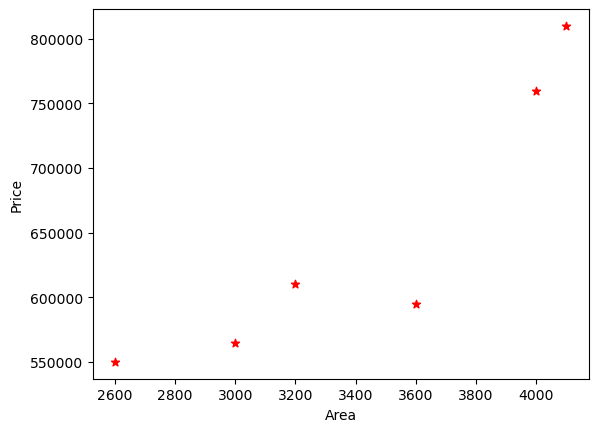

In [5]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df1.area,df1.price,color="red",marker="*")

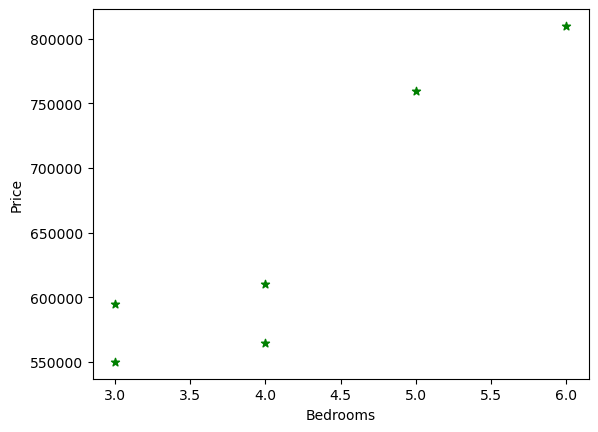

In [6]:
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.scatter(df1.bedrooms,df1.price,color="green",marker="*")

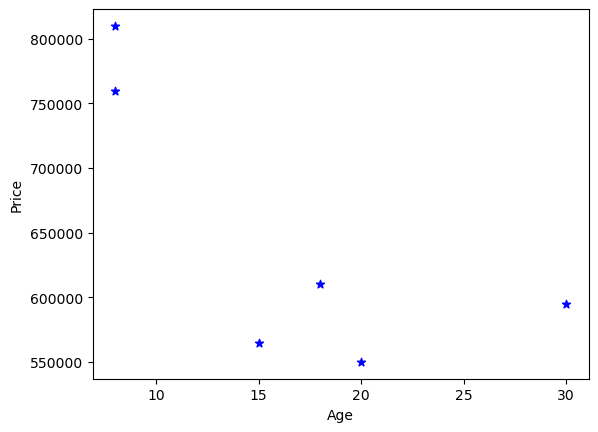

In [7]:
plt.xlabel("Age")
plt.ylabel("Price")
plt.scatter(df1.age,df1.price,color="blue",marker="*")

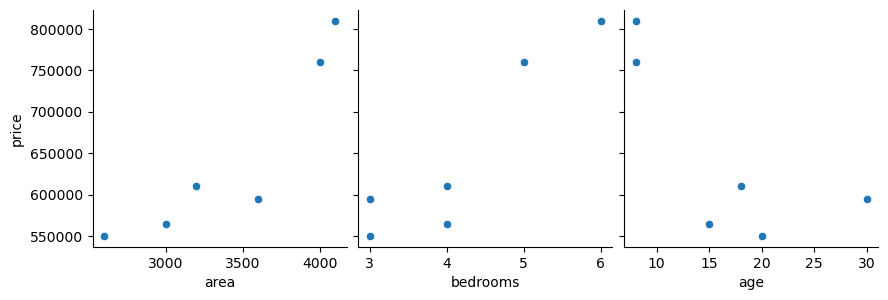

In [8]:
#plotting
import seaborn as sns
sns.pairplot(df1,x_vars=["area","bedrooms","age"],y_vars=["price"],height=3,aspect=1)

In [9]:
x=df1.drop("price",axis=1)
y=df1.price

In [10]:
x

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.0,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [11]:
y

0    550000
1    565000
2    610000
3    595000
4    760000
5    810000
Name: price, dtype: int64

In [12]:
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [13]:
model.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [14]:
model.intercept_

221323.00186540384

In [15]:
y_pred=model.predict(x)
y_pred

array([518217.63297611, 602590.07937407, 615307.4140366 , 597962.89583192,
       760663.42675457, 795258.55102673])

In [16]:
pd.DataFrame({"True y value":y,"predicted y value":y_pred})

,True y value,predicted y value
0,550000,518217.632976
1,565000,602590.079374
2,610000,615307.414037
3,595000,597962.895832
4,760000,760663.426755
5,810000,795258.551027


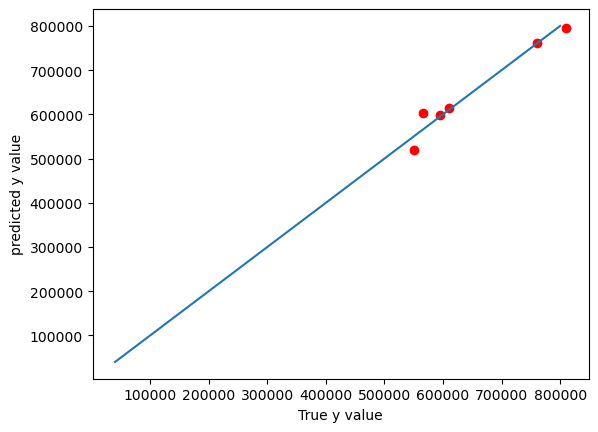

In [17]:
plt.scatter(y,y_pred,color="red")
plt.xlabel("True y value")
plt.ylabel("predicted y value")
plt.plot((40000,800000),(40000,800000))

In [18]:
model.score(x,y)

0.9550196399325819

In [19]:
#Accuracy Measurements
import numpy as np

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("MAE: ",mean_absolute_error(y,y_pred))
print("MSE: ",mean_squared_error(y,y_pred))
print("r2 score: ",r2_score(y,y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y,y_pred)))

MAE:  15507.938665720148
MSE:  446305128.22449297
r2 score:  0.9550196399325819
RMSE:  21125.934966871715


In [21]:
import seaborn as sns

In [22]:
correlation=df1.corr()

In [23]:
correlation

,area,bedrooms,age,price
area,1.000000,0.751710,-0.445300,0.901476
bedrooms,0.751710,1.000000,-0.877221,0.919803
age,-0.445300,-0.877221,1.000000,-0.734167
price,0.901476,0.919803,-0.734167,1.000000


<Axes: >

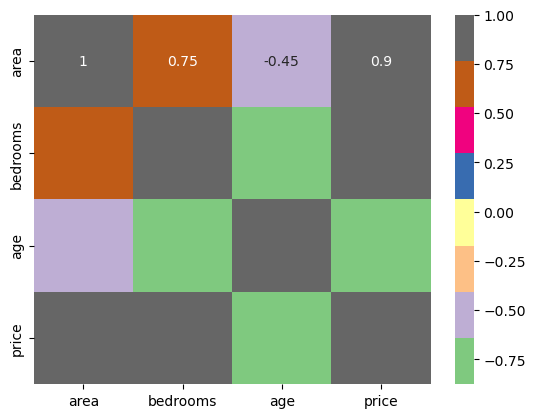

In [24]:
sns.heatmap(correlation,annot=True,cmap='Accent')

In [25]:
model.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [26]:
model.intercept_

221323.00186540384

In [27]:
model.predict([[4000,3,10]])

array([707422.23078143])

In [28]:
(112.06244194*4000+23388.88007794*3+-3231.71790863*10)+221323.00186540408  #m1x1+m1x2+m1x3+c 

707422.2307729241

In [29]:
#pickle is a Python module used for serializing (saving) and deserializing (loading) Python objects.

In [32]:
loaded_hiring.predict([[0,10,10]])

array([422894.62355847])

In [33]:
#another method

In [34]:
import joblib
joblib.dump(model,"hiring_model") 
joblibloaded_hiring=joblib.load("hiring_model")

In [35]:
joblibloaded_hiring.predict([[0,10,10]])

array([422894.62355847])